## 환경/버전 확인
아래 셀을 실행해 현재 환경 버전을 기록해 둡니다.

나중에 같은 결과를 재현하고 환경 차이로 인한 오류를 줄이기 위해 버전을 기록합니다.

In [1]:
import sklearn, numpy as np, pandas as pd
import matplotlib, seaborn

print(f'sklearn: {sklearn.__version__}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {seaborn.__version__}')

sklearn: 1.6.1
numpy: 2.3.3
pandas: 2.3.2
matplotlib: 3.10.6
seaborn: 0.13.2


---
## Part 2. Iris 데이터셋 이해 (EDA)

**목표**
- scikit-learn 내장 데이터셋(Bunch)의 공통 구조를 이해
- Iris 데이터셋의 피처(꽃받침/꽃잎 길이·너비)와 타깃(3개 품종) 파악
- 간단 EDA로 클래스별 차이를 데이터로 확인

### sklearn 내장 데이터셋 구조 (Bunch 객체)

`load_iris()` 등으로 데이터를 로드하면 딕셔너리와 유사한 **Bunch 객체**가 반환

키는 보통 `data`, `target`, `target_names`, `feature_names`, `DESCR`로 구성

| 키 | 내용 |
|----|------|
| `data` | 특성 데이터 (숫자 배열) |
| `target` | 정답 라벨 (숫자 배열) |
| `target_names` | 정답 라벨의 이름 |
| `feature_names` | 특성(컬럼)의 이름 |
| `DESCR` | 데이터셋 설명문 |

In [2]:
from sklearn.datasets import load_iris

iris_data = load_iris()
iris_data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
print(f"키 목록: {list(iris_data.keys())}")

키 목록: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


In [4]:
print(f"feature_names: {iris_data.feature_names}")
print(f"target_names : {iris_data.target_names}")
print(f"data shape   : {iris_data.data.shape}")
print(f"target shape : {iris_data.target.shape}")

feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names : ['setosa' 'versicolor' 'virginica']
data shape   : (150, 4)
target shape : (150,)


### 피처(특성)와 타깃(품종) 의미
- **sepal length (cm)**: 꽃받침 길이
- **sepal width  (cm)**: 꽃받침 너비
- **petal length (cm)**: 꽃잎 길이
- **petal width  (cm)**: 꽃잎 너비

타깃(label)
- 0 = setosa
- 1 = versicolor
- 2 = virginica


### DataFrame 만들기
판다스 DataFrame으로 변환하면 데이터를 훨씬 편하게 다룰 수 있습니다.

In [5]:
# import pandas as pd
#
# iris = load_iris()
#
# iris_data = iris.data
#
# iris_label = iris.target
# print('iris target값:', iris_label)
# print('iris target명:', iris.target_names)
#
# iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
# iris_df['label'] = iris.target
# iris_df.head(3)

In [6]:
import pandas as pd

df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df["label"] = iris_data.target
label_map = {i: name for i, name in enumerate(iris_data.target_names)}
df["species"] = df["label"].map(label_map)
df.head()
list(label_map)

[0, 1, 2]

---
### [실습] 데이터 구조 파악 체크리스트

> 새로운 데이터를 만나면 **가장 먼저** 해야 할 것들입니다.
> 판다스에서 배운 것들을 여기서 바로 활용합니다!

In [7]:
# 1단계: 데이터 크기 확인 — 몇 행, 몇 열?
print(f"데이터 크기: {df.shape}")
print(f"  → {df.shape[0]}개의 샘플, {df.shape[1]}개의 컬럼")

데이터 크기: (150, 6)
  → 150개의 샘플, 6개의 컬럼


In [8]:
# 2단계: 각 컬럼의 데이터 타입 확인
# 숫자(float64, int64)인지, 문자(object)인지에 따라 전처리 방법이 달라짐
print("각 컬럼의 데이터 타입:")
print(df.dtypes)

각 컬럼의 데이터 타입:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
label                  int64
species               object
dtype: object


In [9]:
# 3단계: 데이터 전체 요약 — info()는 타입, 결측치, 메모리까지 한번에!
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   label              150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


---
### [실습] 결측치(Missing Values) 확인

> **결측치** = 비어있는 데이터 (NaN).  
> 결측치가 있으면 모델이 학습할 수 없거나 성능이 떨어짐
> 실무 데이터에서는 결측치가 매우 흔하므로, 항상 확인하는 습관이 중요함

In [10]:
# 컬럼별 결측치 수 확인
print("컬럼별 결측치 수:")
print(df.isnull().sum())

print(f"\n전체 결측치 비율: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.1f}%")

# Iris는 결측치가 없는 깨끗한 데이터임(미끼임!)
# 실무 데이터에서는 거의 반드시 결측치가 존재함

컬럼별 결측치 수:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
label                0
species              0
dtype: int64

전체 결측치 비율: 0.0%


> **결측치가 있다면?**
> - 해당 행을 삭제: `df.dropna()`
> - 평균값으로 채우기: `df.fillna(df.mean())`
> - 중앙값으로 채우기: `df.fillna(df.median())`
> - sklearn의 `SimpleImputer` 사용 (나중에 배움)
>
> 어떤 방법을 쓸지는 **데이터의 특성**에 따라 다름₩.

---
### [실습] Target(정답) 분포 확인

> 클래스별 데이터 개수가 **균등한지** 확인하는 것이 중요합니다.  
> 한쪽 클래스만 많으면 모델이 편향될 수 있습니다. ("불균형 데이터" 문제)

In [11]:
# Target 분포 확인 — value_counts()로 각 클래스의 개수 세기
print("품종별 데이터 수:")
print(df["species"].value_counts())

print(f"\n비율 (normalize=True로 비율 확인):")
print(df["species"].value_counts(normalize=True).round(3))

# 각 품종이 50개씩, 33.3%로 완벽하게 균등! → 좋은 데이터

품종별 데이터 수:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

비율 (normalize=True로 비율 확인):
species
setosa        0.333
versicolor    0.333
virginica     0.333
Name: proportion, dtype: float64


In [12]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'   # 맥
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False # 한글 폰트 사용 시, 마이너스 글자가 깨지는 현상 해결

In [13]:
# # Target 분포 시각화
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# # 막대 그래프
# df["species"].value_counts().plot(kind="bar", ax=axes[0], color=["#4a9eff", "#ff6b6b", "#51cf66"])
# axes[0].set_title("품종별 데이터 수")
# axes[0].set_ylabel("개수")

# # 파이 차트 — 비율 확인에 직관적
# df["species"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
#                                    colors=["#4a9eff", "#ff6b6b", "#51cf66"])
# axes[1].set_title("품종별 비율")
# axes[1].set_ylabel("")

# plt.tight_layout()
# plt.show()

# Target 분포 시각화
import plotly.express as px
df_species = df['species'].value_counts().reset_index()

# 막대 그래프
fig_bar = px.bar(df_species, x='species', y='count',
                 title='품종별 데이터 수', color='species')
fig_bar.show()

# 파이 차트-비율 확인에 직관적
fig_pie = px.pie(df_species, names='species', values='count', title='품종별 비율', hole=0)
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

---
### 기본 통계 확인

In [14]:
# describe(): count, mean, std, min, 25%, 50%, 75%, max 한번에
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


> **describe()에서 봐야 할 포인트:**
> - `count`: 결측치가 있으면 컬럼마다 count가 다름
> - `mean`과 `std`: 데이터의 중심과 퍼진 정도
> - `min`과 `max`: 이상치가 있는지 확인
> - `25%`, `50%`, `75%`: 데이터의 분포 형태 파악

In [15]:
df.groupby("species")[iris_data.feature_names].mean().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


> **관찰:**
> - `petal length/width`: 품종 간 차이가 매우 뚜렷 → 분류에 유리한 피처!
> - `sepal width`: 품종 간 차이가 상대적으로 작음 → 분류에 덜 유리

---
### 시각화 EDA

> 모델을 돌리기 전에 데이터가 어떻게 생겼는지 **눈으로** 확인하셈
> 시각화를 통해 예측 난이도를 미리 가늠하고, 어떤 알고리즘이 적합할지 판단할 수 있음

In [16]:
import plotly.express as px

fig = px.scatter(
    df,
    x="petal length (cm)",
    y="petal width (cm)",
    color="species",
    title="Iris: 꽃잎 길이 대 너비 (Petal)"
)
fig.show()

In [17]:
fig = px.scatter(
    df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    color="species",
    title="Iris: 꽃받침 길이 대 너비 (Sepal)"
)
fig.show()

> **산점도에서 읽어내야 할 것:**
> - 꽃잎(petal) 그래프: setosa가 완전히 분리됨 → 쉽게 구분 가능
> - 꽃받침(sepal) 그래프: 세 품종이 많이 겹침 → 이 피처만으로는 분류 어려움
> - versicolor와 virginica는 꽃잎 그래프에서도 일부 겹침 → 모델이 헷갈릴 수 있는 구간

In [18]:
# sns.histplot(
#     data=df, x="petal length (cm)", hue="species",
#     element="step", stat="density", common_norm=False
# )
# plt.title("Iris: Petal length distribution by species")
# plt.show()

# 히스토그램: 특정 피처의 분포를 품종별로 비교
fig = px.histogram(
    df,
    x="petal length (cm)",
    color="species",
    barmode="overlay",
    nbins=20,
    title="Iris: 꽃잎 길이(Petal Length) 분포"
)
fig.update_traces(opacity=0.6)
fig.show()

---
### [실습] 전체 피처 관계 한눈에 보기 (Pairplot)

> 모든 피처 조합의 산점도를 한 번에 그립니다.  
> 어떤 피처 조합이 분류에 유리한지 **한 장**으로 파악할 수 있습니다.

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

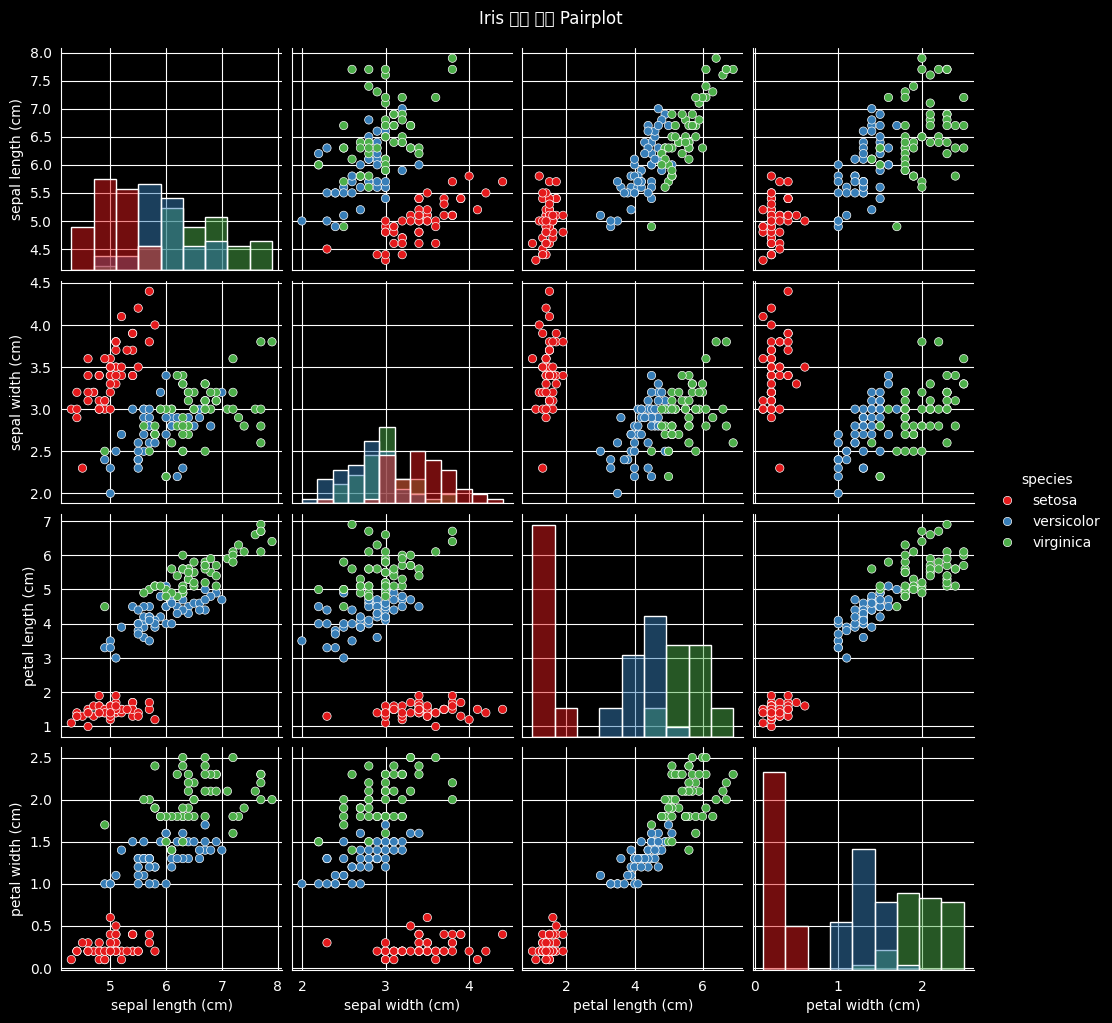

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# pairplot: 모든 피처 조합의 산점도 + 대각선에 히스토그램
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist", # 대각선 히스토그램으로 채워짐
    vars=iris_data.feature_names,
    palette="Set1"
)
plt.suptitle("Iris 전체 피처 Pairplot", y=1.02)
plt.show()

> **Pairplot 읽는 법:**
> - 대각선: 각 피처의 히스토그램 (분포)
> - 대각선 아래/위: 두 피처 조합의 산점도
> - 색이 잘 분리되는 조합 = 분류에 유리한 피처 조합
> - petal length + petal width 조합이 가장 잘 분리됨!

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

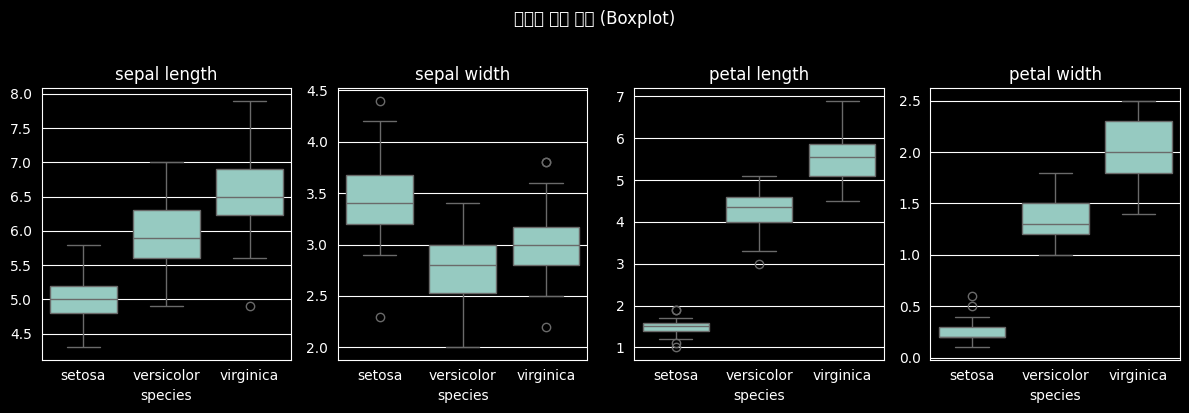

In [21]:
# 박스플롯: 품종별 피처 분포 비교
plt.figure(figsize=(12, 4))

for i, feature in enumerate(iris_data.feature_names):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(feature.replace(" (cm)", ""))
    if i >= 0:
        plt.ylabel("")

plt.suptitle("품종별 피처 분포 (Boxplot)", y=1.02)
plt.tight_layout()
plt.show()

> **박스플롯 읽는 법:**
> - 상자 = 데이터의 25%~75% 구간 (IQR)
> - 상자 안의 선 = 중앙값 (50%)
> - 수염 = 상자에서 1.5 x IQR 범위
> - 수염 밖의 점 = 이상치(outlier)
> - 상자가 겹치지 않는 피처 → 분류에 유리!

---
### [실습] 상관관계 확인

> 피처들 간의 관계를 숫자로 확인합니다.  
> **상관계수**: 1에 가까우면 강한 양의 상관, -1에 가까우면 강한 음의 상관, 0이면 관계 없음

In [22]:
# 수치 피처만 추출해서 상관행렬 계산
corr = df[iris_data.feature_names].corr().round(2)
print("피처 간 상관계수:")
print(corr)

피처 간 상관계수:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)               1.00             -0.12               0.87   
sepal width (cm)               -0.12              1.00              -0.43   
petal length (cm)               0.87             -0.43               1.00   
petal width (cm)                0.82             -0.37               0.96   

                   petal width (cm)  
sepal length (cm)              0.82  
sepal width (cm)              -0.37  
petal length (cm)              0.96  
petal width (cm)               1.00  


In [23]:
# # 상관행렬 히트맵 — 색으로 직관적 확인
# plt.figure(figsize=(7, 5))
# sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1,
#             square=True, linewidths=1)
# plt.title("피처 간 상관관계 (Correlation Matrix)")
# plt.show()

# 상관행렬 히트맵- 색으로 직관적 확인
fig=px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r')
fig.update_layout(title='피처 간 상관관계 (Correlation Matrix)')
fig.show()

> **상관관계에서 읽어내야 할 것:**
> - `petal length`와 `petal width`의 상관계수 ≈ 0.96 → 매우 강한 양의 상관 (함께 커짐)
> - `sepal width`는 다른 피처들과 상관이 낮음 → 독립적인 정보를 제공
> - 상관이 너무 높은 피처들은 중복 정보일 수 있음 → 나중에 피처 선택/제거 고려

In [24]:
# 품종별 평균 특성 히트맵
group_means = df.groupby("species")[iris_data.feature_names].mean()

fig = px.imshow(
    group_means,
    text_auto=True,
    aspect="auto",
    color_continuous_scale="Blues",
    title="품종별 평균 특성 (Heatmap)"
)

fig.update_xaxes(title="특성(feature)")
fig.update_yaxes(title="품종(species)")

fig.show()

### EDA 요약
- **setosa**는 꽃잎 길이/너비가 매우 작아 쉽게 구분
- **versicolor**와 **virginica**는 꽃잎 분포가 일부 겹쳐 모델이 헷갈릴 수 있음
- **petal length / petal width**가 분류에 가장 유리한 피처
- 결측치 없음, 클래스 균등 → 깨끗한 교육용 데이터

---
## EDA 체크리스트 정리

새로운 데이터셋을 만나면 이 순서로:

| 순서 | 코드 | 확인하는 것 |
|------|------|-------------|
| 1 | `df.shape` | 몇 행, 몇 열? |
| 2 | `df.dtypes` / `df.info()` | 각 컬럼의 데이터 타입 |
| 3 | `df.isnull().sum()` | 결측치 있나? |
| 4 | `df.describe()` | 기본 통계 (평균, 표준편차, 최솟값, 최댓값) |
| 5 | `df["target"].value_counts()` | 클래스 분포 균등한가? |
| 6 | 산점도 / 박스플롯 / 히스토그램 | 시각적 패턴 확인 |
| 7 | `df.corr()` + 히트맵 | 피처 간 상관관계 |

> 이 과정 없이 모델을 돌리면, **왜 성능이 안 나오는지 알 수 없습니다.**

---
## 참고: sklearn 내장 데이터셋 더 살펴보기

Iris 외에도 sklearn에는 여러 내장 데이터셋이 있습니다.  
모두 동일한 Bunch 구조를 가지고 있어서, 위에서 배운 방법을 그대로 적용할 수 있습니다.

In [25]:
from sklearn.datasets import load_breast_cancer, load_diabetes

bc = load_breast_cancer()    # 유방암 이진 분류 (악성/양성)
dia = load_diabetes()        # 당뇨병 회귀 (수치 예측)

print(f"Breast Cancer: {bc.data.shape}, 분류={bc.target_names}")
print(f"Diabetes     : {dia.data.shape}, 회귀 (타겟=수치)")

# Bunch 구조가 동일! → 키만 바꾸면 같은 코드로 분석 가능
print(f"\nBreast Cancer keys: {list(bc.keys())}")
print(f"Diabetes keys     : {list(dia.keys())}")

Breast Cancer: (569, 30), 분류=['malignant' 'benign']
Diabetes     : (442, 10), 회귀 (타겟=수치)

Breast Cancer keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
Diabetes keys     : ['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module']


---
## 모델은 이렇게 사용됩니다 (미리보기)

머신러닝 모델은 보통 이 3단계로 사용됩니다.

1. **fit** — 데이터로부터 규칙을 학습
2. **predict** — 처음 보는 데이터 예측
3. **score** — 예측이 얼마나 맞았는지 평가

모델이 달라져도 이 패턴은 **동일**합니다!

In [26]:
# 맛보기: 모델 사용 패턴 (다음 시간에 자세히!)
from sklearn.tree import DecisionTreeClassifier

# 1. 모델 생성
model = DecisionTreeClassifier()

# 2. 학습 (fit) — 데이터의 패턴을 학습
# model.fit(X_train, y_train)

# 3. 예측 (predict) — 새로운 데이터로 예측
# y_pred = model.predict(X_test)

# 4. 평가 (score) — 정확도 확인
# accuracy = model.score(X_test, y_test)

print("다음 시간에 직접 실행해 봅니다!")

다음 시간에 직접 실행해 봅니다!


> 다음 시간에는 이 과정을 **직접 실습**해봅니다.

---
## 다음 시간 예고

**2회차: 첫 모델 & 모델 선택 기초**

- **첫 번째 모델 실습**: DecisionTree로 fit → predict → score 체험
- **모델 교체**: LogisticRegression, KNN으로 바꿔보기
- **Train/Test Split**: 왜 나눠야 하는지 직접 확인 (accuracy 1.0 착시)
- **교차검증 (K-Fold)**: 한 번 나누기는 운에 좌우 → 여러 번 나눠 평균
- **cross_val_score**: 한 줄로 교차검증 실행
- **GridSearchCV**: 하이퍼파라미터 후보를 공정하게 비교

> 오늘 EDA로 데이터를 파악했으니,  
> 다음엔 **모델을 학습하고 평가하는 전체 흐름**을 익힙니다.